# 01 — Analyse Exploratoire des Données (EDA)
## Projet : Prédiction de la Dépression étudiante — `student_lifestyle_100k`

**Variable cible :** `Depression` (booléen : `True` / `False`)
**Algorithme imposé :** Kernel SVM
**Objectif de ce notebook :** comprendre le dataset en profondeur avant tout prétraitement ou modélisation — structure, qualité, distributions, corrélations et relation de chaque variable avec la cible.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv("../dataset/student_lifestyle_100k.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (100000, 11)


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


## 1. Compréhension du problème

Le dataset contient des informations de mode de vie et académiques d'étudiants. L'objectif est de prédire si un étudiant présente des signes de **dépression** (`Depression`) à partir de variables comme le sommeil, le temps d'étude, l'usage des réseaux sociaux, l'activité physique, le niveau de stress perçu, ainsi que des variables démographiques (âge, genre, département, CGPA).

Il s'agit d'un problème de **classification binaire supervisée**, avec un enjeu de santé mentale : les faux négatifs (étudiants dépressifs non détectés) sont particulièrement coûteux, ce qui orientera notre choix de métriques (privilégier le rappel / F1 en plus de l'accuracy).


## 2. Analyse des variables

On distingue :
- **Identifiant** : `Student_ID` (à exclure de la modélisation, aucune valeur prédictive)
- **Variables numériques continues** : `Age`, `CGPA`, `Sleep_Duration`, `Study_Hours`, `Social_Media_Hours`, `Physical_Activity`, `Stress_Level`
- **Variables catégorielles** : `Gender`, `Department`
- **Variable cible** : `Depression` (booléen)


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [3]:
print("Valeurs uniques par colonne catégorielle :")
for c in ["Gender", "Department", "Depression"]:
    print(f"  {c}: {df[c].unique().tolist()}")

print("\nÉtendue des variables numériques :")
num_cols = ["Age", "CGPA", "Sleep_Duration", "Study_Hours", "Social_Media_Hours", "Physical_Activity", "Stress_Level"]
df[num_cols].agg(["min", "max"]).T

Valeurs uniques par colonne catégorielle :
  Gender: ['Female', 'Male']
  Department: ['Science', 'Engineering', 'Medical', 'Arts', 'Business']
  Depression: [False, True]

Étendue des variables numériques :


,min,max
Age,18.00,24.0
CGPA,1.56,4.0
Sleep_Duration,3.00,12.0
Study_Hours,0.00,12.8
Social_Media_Hours,0.00,10.0
Physical_Activity,0.00,149.0
Stress_Level,2.00,10.0


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,100000.0,NaN,NaN,NaN,51000.5,28867.657797,1001.0,26000.75,51000.5,76000.25,101000.0
Age,100000.0,NaN,NaN,NaN,21.00901,2.000382,18.0,19.0,21.0,23.0,24.0
Gender,100000,2,Male,50120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,100000,5,Science,20071,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CGPA,100000.0,NaN,NaN,NaN,2.898316,0.53224,1.56,2.45,2.9,3.35,4.0
Sleep_Duration,100000.0,NaN,NaN,NaN,6.996425,1.498682,3.0,6.0,7.0,8.0,12.0
Study_Hours,100000.0,NaN,NaN,NaN,4.509517,1.976076,0.0,3.2,4.5,5.8,12.8
Social_Media_Hours,100000.0,NaN,NaN,NaN,3.503288,1.486852,0.0,2.5,3.5,4.5,10.0
Physical_Activity,100000.0,NaN,NaN,NaN,74.35318,43.366963,0.0,37.0,74.0,112.0,149.0
Stress_Level,100000.0,NaN,NaN,NaN,4.13166,1.424151,2.0,3.0,4.0,5.0,10.0


## 3. Valeurs manquantes

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(3)
missing_report = pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
missing_report

,n_missing,pct_missing
Student_ID,0,0.0
Age,0,0.0
Gender,0,0.0
Department,0,0.0
CGPA,0,0.0
Sleep_Duration,0,0.0
Study_Hours,0,0.0
Social_Media_Hours,0,0.0
Physical_Activity,0,0.0
Stress_Level,0,0.0


## 4. Doublons

In [6]:
full_dupes = df.duplicated().sum()
id_dupes = df["Student_ID"].duplicated().sum()
print(f"Lignes entièrement dupliquées : {full_dupes}")
print(f"Student_ID dupliqués : {id_dupes}")

Lignes entièrement dupliquées : 0
Student_ID dupliqués : 0


## 5. Valeurs aberrantes (outliers)

Détection par la méthode IQR (1.5×IQR) sur chaque variable numérique continue.


In [7]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask.sum(), lower, upper

outlier_report = []
for c in num_cols:
    n_out, lo, hi = iqr_outliers(df[c])
    outlier_report.append({"variable": c, "n_outliers": n_out, "pct_outliers": round(n_out / len(df) * 100, 3), "lower_bound": round(lo, 2), "upper_bound": round(hi, 2)})
pd.DataFrame(outlier_report)

,variable,n_outliers,pct_outliers,lower_bound,upper_bound
0,Age,0,0.000,13.0,29.0
1,CGPA,0,0.000,1.1,4.7
2,Sleep_Duration,369,0.369,3.0,11.0
3,Study_Hours,432,0.432,-0.7,9.7
4,Social_Media_Hours,328,0.328,-0.5,7.5
5,Physical_Activity,0,0.000,-75.5,224.5
6,Stress_Level,478,0.478,0.0,8.0


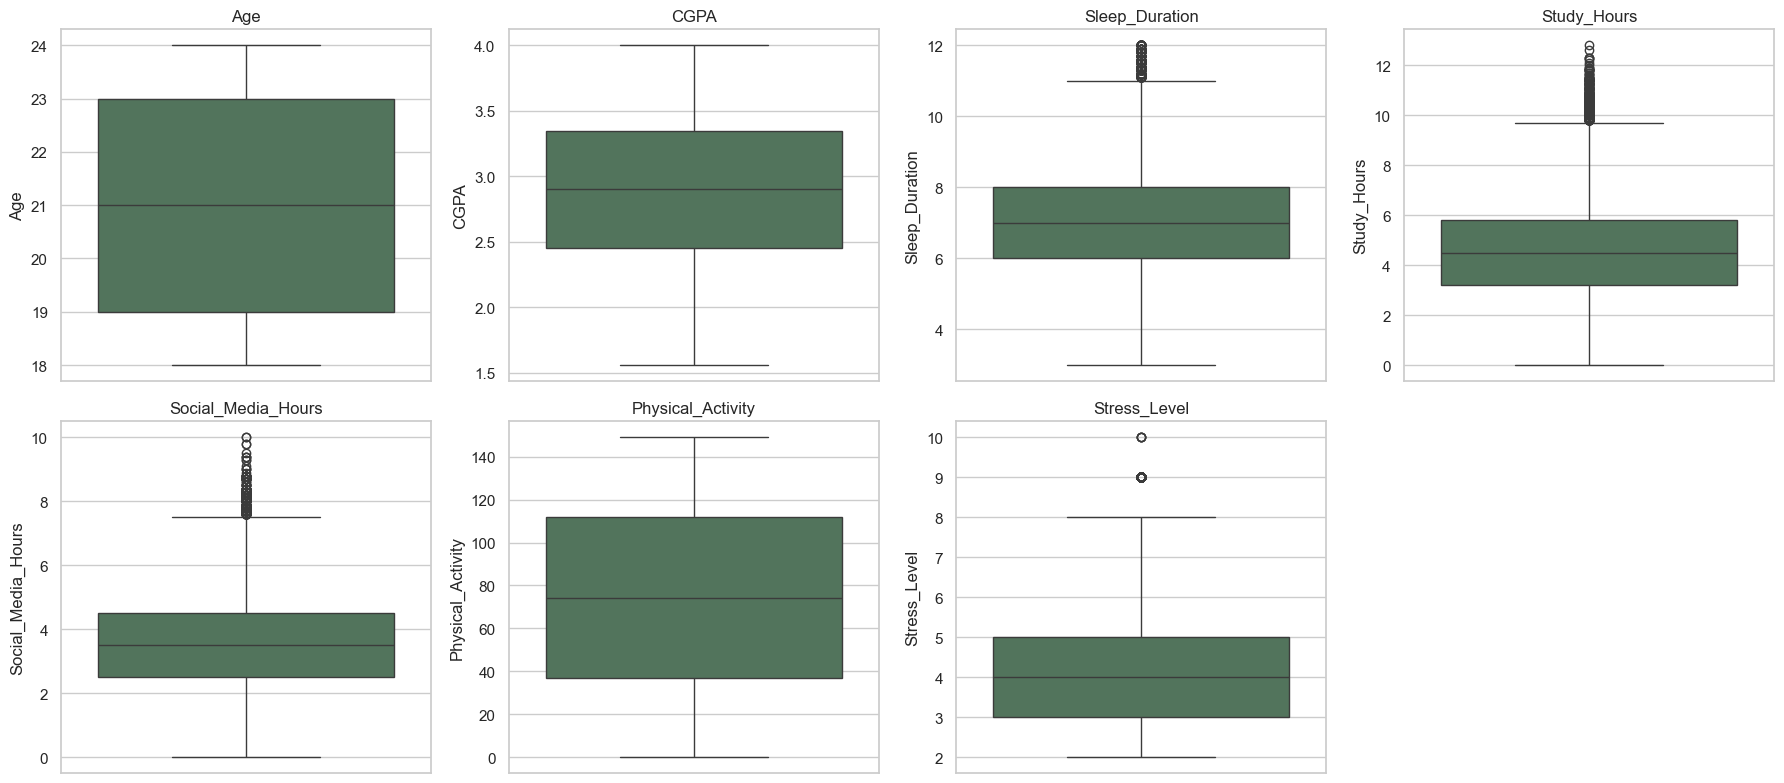

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.flat, num_cols):
    sns.boxplot(y=df[c], ax=ax, color="#4C7A5A")
    ax.set_title(c)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "outliers_boxplots.png", bbox_inches="tight")
plt.show()

## 6. Distributions des variables

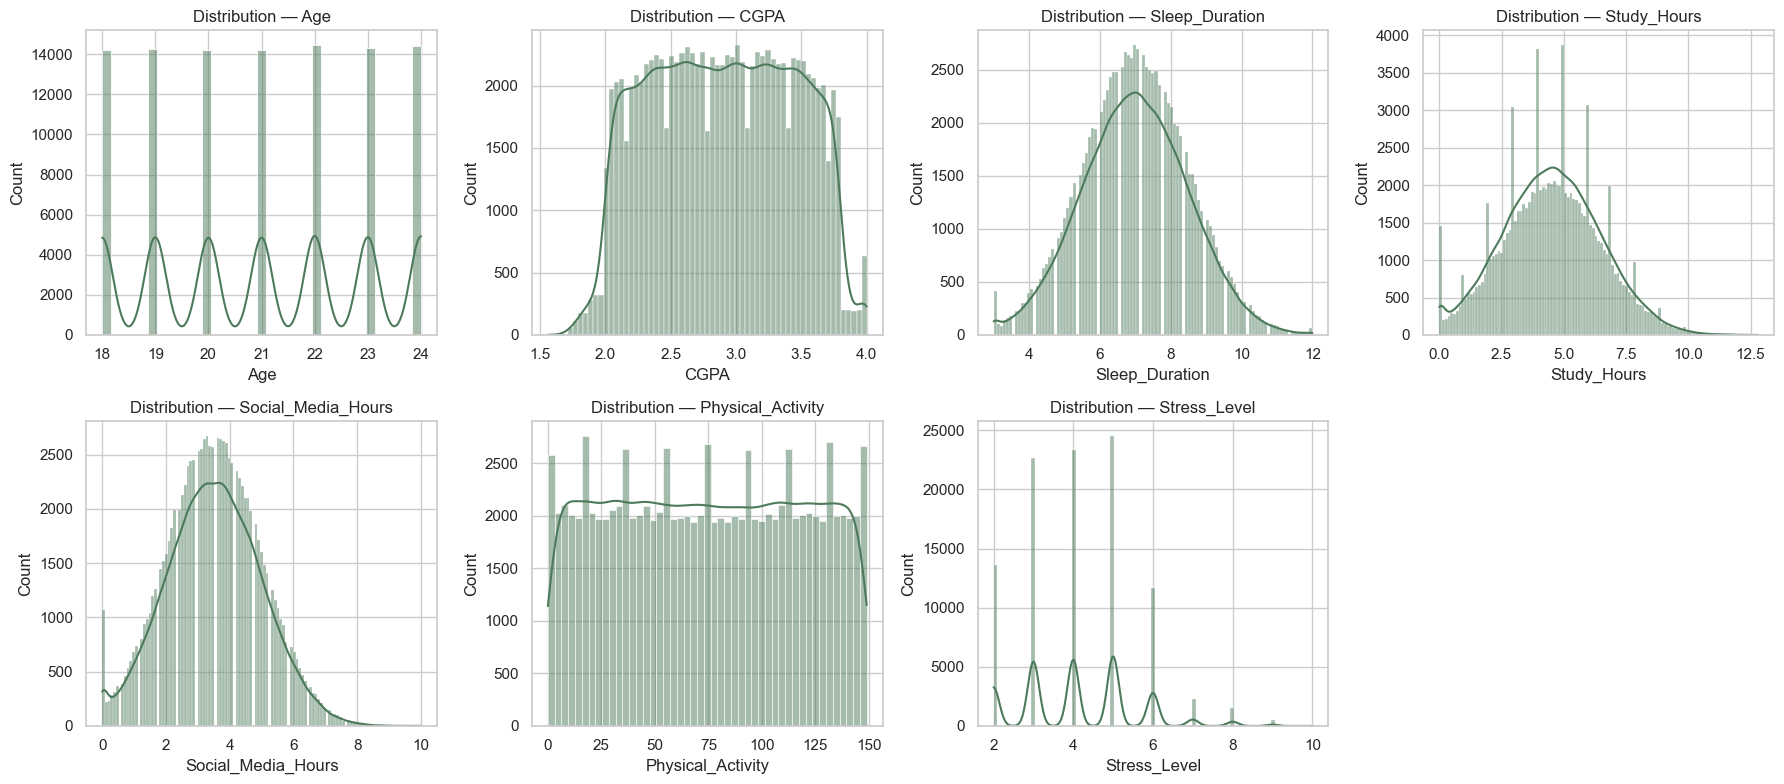

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.flat, num_cols):
    sns.histplot(df[c], kde=True, ax=ax, color="#4C7A5A")
    ax.set_title(f"Distribution — {c}")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "distributions_numeric.png", bbox_inches="tight")
plt.show()

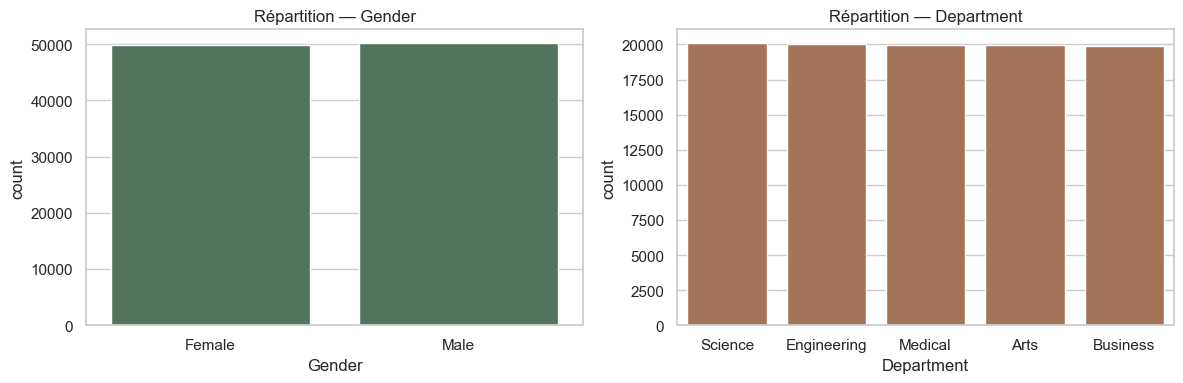

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="Gender", data=df, ax=axes[0], color="#4C7A5A")
axes[0].set_title("Répartition — Gender")
sns.countplot(x="Department", data=df, ax=axes[1], color="#B0714A")
axes[1].set_title("Répartition — Department")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "distributions_categorical.png", bbox_inches="tight")
plt.show()

## 7. Corrélations

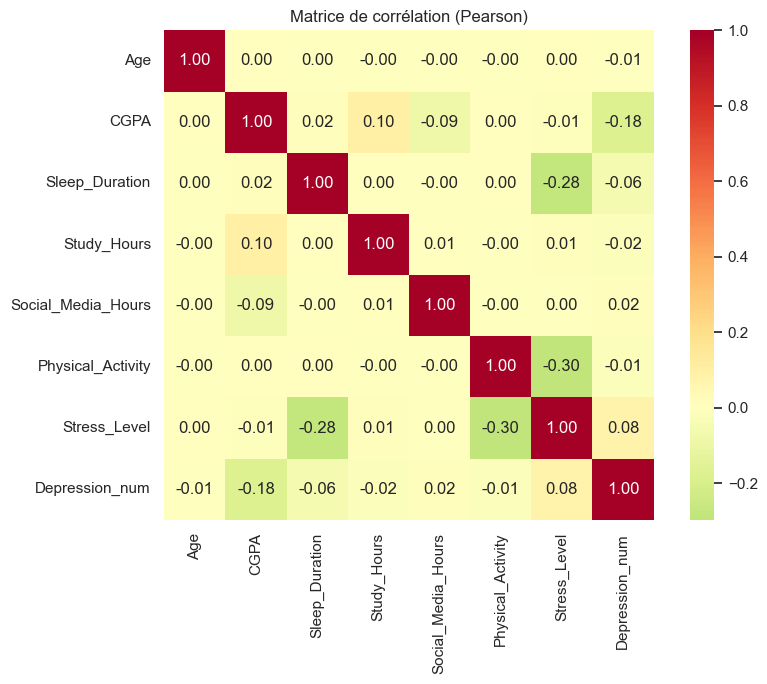


Corrélation de chaque variable avec Depression, triée :


CGPA                 -0.178971
Stress_Level          0.075866
Sleep_Duration       -0.057529
Social_Media_Hours    0.016771
Study_Hours          -0.015932
Physical_Activity    -0.013935
Age                  -0.007722
Name: Depression_num, dtype: float64

In [11]:
df_corr = df.copy()
df_corr["Depression_num"] = df_corr["Depression"].astype(int)
corr = df_corr[num_cols + ["Depression_num"]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0, square=True)
plt.title("Matrice de corrélation (Pearson)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("\nCorrélation de chaque variable avec Depression, triée :")
corr["Depression_num"].drop("Depression_num").sort_values(key=abs, ascending=False)

## 8. Analyse de la variable cible

Depression
False    89938
True     10062
Name: count, dtype: int64
Depression
False    89.94
True     10.06
Name: proportion, dtype: float64


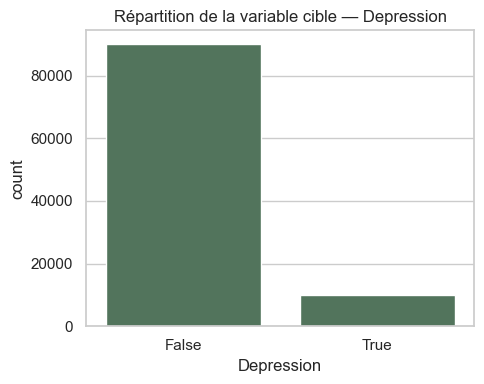

In [12]:
target_counts = df["Depression"].value_counts()
target_pct = df["Depression"].value_counts(normalize=True).mul(100).round(2)
print(target_counts)
print(target_pct)

plt.figure(figsize=(5, 4))
sns.countplot(x="Depression", data=df, color="#4C7A5A")
plt.title("Répartition de la variable cible — Depression")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "target_distribution.png", bbox_inches="tight")
plt.show()

## 9. Déséquilibre des classes

In [13]:
majority = target_counts.max()
minority = target_counts.min()
ratio = round(majority / minority, 2)
print(f"Classe majoritaire : {target_counts.idxmax()} ({majority} obs.)")
print(f"Classe minoritaire : {target_counts.idxmin()} ({minority} obs.)")
print(f"Ratio de déséquilibre : {ratio}:1")

Classe majoritaire : False (89938 obs.)
Classe minoritaire : True (10062 obs.)
Ratio de déséquilibre : 8.94:1


## 10. Relation bivariée entre chaque variable et la cible

Avant de conclure, on regarde comment chaque variable se comporte selon la classe `Depression`, ce qui oriente le feature engineering (Phase 2).


C:\Users\FTAB TECH\AppData\Local\Temp\ipykernel_24324\3182892154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Depression", y=c, data=df, ax=ax, palette=["#4C7A5A", "#C97B5A"])


C:\Users\FTAB TECH\AppData\Local\Temp\ipykernel_24324\3182892154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Depression", y=c, data=df, ax=ax, palette=["#4C7A5A", "#C97B5A"])


C:\Users\FTAB TECH\AppData\Local\Temp\ipykernel_24324\3182892154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Depression", y=c, data=df, ax=ax, palette=["#4C7A5A", "#C97B5A"])


C:\Users\FTAB TECH\AppData\Local\Temp\ipykernel_24324\3182892154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Depression", y=c, data=df, ax=ax, palette=["#4C7A5A", "#C97B5A"])


C:\Users\FTAB TECH\AppData\Local\Temp\ipykernel_24324\3182892154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Depression", y=c, data=df, ax=ax, palette=["#4C7A5A", "#C97B5A"])


C:\Users\FTAB TECH\AppData\Local\Temp\ipykernel_24324\3182892154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Depression", y=c, data=df, ax=ax, palette=["#4C7A5A", "#C97B5A"])


C:\Users\FTAB TECH\AppData\Local\Temp\ipykernel_24324\3182892154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Depression", y=c, data=df, ax=ax, palette=["#4C7A5A", "#C97B5A"])


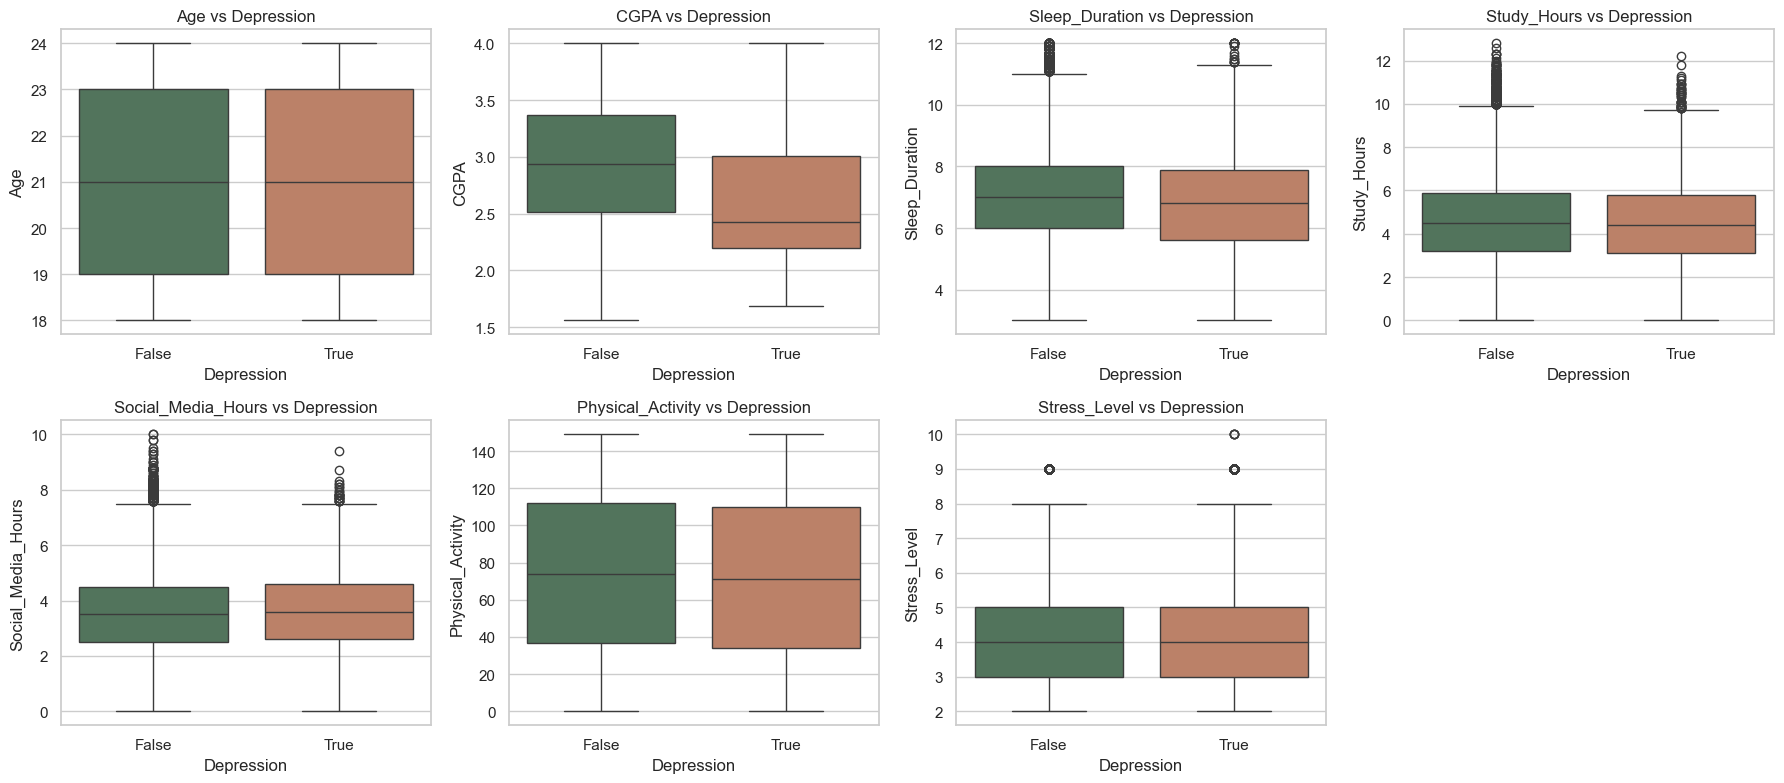

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.flat, num_cols):
    sns.boxplot(x="Depression", y=c, data=df, ax=ax, palette=["#4C7A5A", "#C97B5A"])
    ax.set_title(f"{c} vs Depression")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "bivariate_numeric_vs_target.png", bbox_inches="tight")
plt.show()

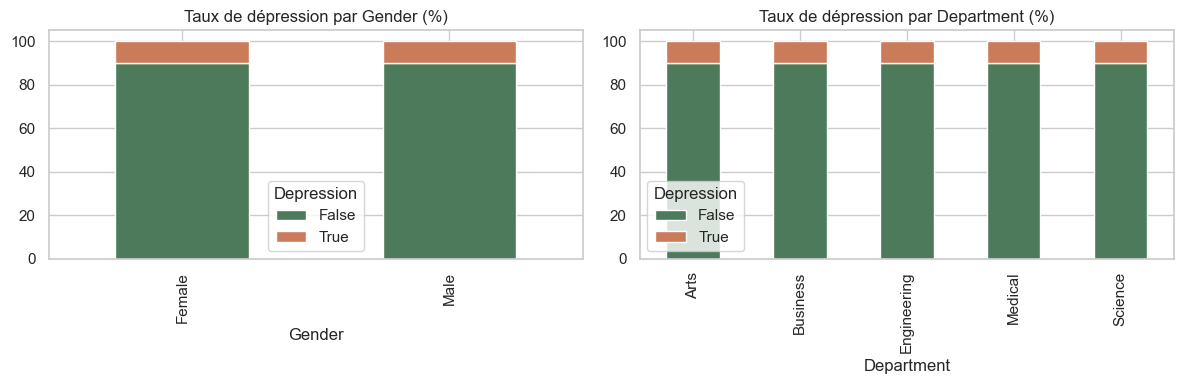

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.crosstab(df["Gender"], df["Depression"], normalize="index").mul(100).plot(kind="bar", stacked=True, ax=axes[0], color=["#4C7A5A", "#C97B5A"])
axes[0].set_title("Taux de dépression par Gender (%)")
axes[0].legend(title="Depression")
pd.crosstab(df["Department"], df["Depression"], normalize="index").mul(100).plot(kind="bar", stacked=True, ax=axes[1], color=["#4C7A5A", "#C97B5A"])
axes[1].set_title("Taux de dépression par Department (%)")
axes[1].legend(title="Depression")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "bivariate_categorical_vs_target.png", bbox_inches="tight")
plt.show()

## 11. Conclusions

- **Qualité des données** : dataset propre — **0 valeur manquante**, **0 doublon** (ni sur les lignes complètes, ni sur `Student_ID`). Aucun nettoyage de qualité n'est nécessaire en Phase 2.
- **Déséquilibre des classes** : la cible est déséquilibrée — `Depression=False` représente 89.94 % (89 938 obs.) contre 10.06 % (10 062 obs.) pour `Depression=True`, soit un **ratio de 8.94:1**. Cela devra être géré en Phase 2 (`class_weight="balanced"` pour le SVM) et pris en compte dans le choix des métriques d'évaluation (F1 / rappel de la classe minoritaire plutôt que la seule accuracy, qui serait trompeuse — un modèle prédisant toujours `False` atteindrait déjà ~90 % d'accuracy).
- **Corrélations avec la cible** : toutes les corrélations linéaires (Pearson) sont **faibles** — `CGPA` (-0.18) est la plus forte, suivie de `Stress_Level` (+0.08) et `Sleep_Duration` (-0.06) ; `Social_Media_Hours`, `Study_Hours`, `Physical_Activity` et `Age` sont quasi nulles (|r| < 0.02). Ceci suggère qu'il n'existe **pas de frontière de décision linéaire simple** entre les classes — un argument en faveur du **Kernel SVM** (imposé par le sujet), capable de capturer des relations non linéaires qu'une régression logistique ou un SVM linéaire manqueraient.
- **Variables catégorielles** : `Gender` et `Department` nécessiteront un encodage (one-hot) avant utilisation dans un SVM à noyau, qui est sensible à l'échelle des features → une **standardisation (`StandardScaler`)** sera indispensable en Phase 2.
- **Outliers (IQR)** : présence limitée — `Stress_Level` (0.48 %), `Study_Hours` (0.43 %), `Sleep_Duration` (0.37 %), `Social_Media_Hours` (0.33 %) ; `Age`, `CGPA`, `Physical_Activity` n'en ont aucun. Cohérent avec un dataset synthétique borné — pas de traitement agressif nécessaire, à réévaluer si les performances du modèle final sont dégradées.

**Implications pour la Phase 2 (Prétraitement)** : encodage one-hot des variables catégorielles, standardisation obligatoire de toutes les variables numériques, gestion du déséquilibre via `class_weight="balanced"`, exclusion de `Student_ID`, split stratifié train/test pour préserver le ratio 8.94:1 dans les deux sous-ensembles.


In [16]:
summary = {
    "n_rows": len(df),
    "n_cols": df.shape[1],
    "n_missing_total": int(df.isnull().sum().sum()),
    "n_duplicates": int(full_dupes),
    "target_imbalance_ratio": ratio,
    "depression_true_pct": float(target_pct.get(True, 0)),
    "depression_false_pct": float(target_pct.get(False, 0)),
}
print("=== Synthèse EDA ===")
for k, v in summary.items():
    print(f"{k}: {v}")

=== Synthèse EDA ===
n_rows: 100000
n_cols: 11
n_missing_total: 0
n_duplicates: 0
target_imbalance_ratio: 8.94
depression_true_pct: 10.06
depression_false_pct: 89.94
